# Corduroy: ERA5 Reanalysis + NeuralGCM Forecast

This notebook demonstrates the full pipeline:
1. **ERA5 reanalysis** — fetch historical precipitation via corduroy (Rust I/O)
2. **NeuralGCM forecast** — run a forward prediction from ERA5 initial conditions (JAX)
3. **Compare** — visualize reanalysis vs forecast side by side

### Setup
```bash
# From repo root:
uv sync --dev                          # base deps + notebook
uv sync --group forecast               # adds neuralgcm, jax, xarray (GPU recommended)
```

## Part 1: ERA5 Reanalysis via Corduroy (Rust)

Fetch historical precipitation for a bounding box. This calls Rust code via PyO3 — data is read from the ARCO ERA5 Zarr v3 store on GCS (public, no credentials).

In [1]:
import corduroy
import numpy as np
import matplotlib.pyplot as plt

# Central US — a region that frequently has precipitation
bbox = corduroy.BoundingBox(35.0, 45.0, -90.0, -75.0)
datetime_str = "2023-06-15T12:00:00"

print(f"Fetching ERA5 precipitation for {bbox}")
print(f"Datetime: {datetime_str}")

field = corduroy.fetch_precipitation(bbox, datetime_str)

print(f"\nShape: {field.shape}")
print(f"Lat range: {field.latitudes[0]:.2f} to {field.latitudes[-1]:.2f}")
print(f"Lon range: {field.longitudes[0]:.2f} to {field.longitudes[-1]:.2f}")

vmin, vmax = field.value_range()
print(f"Precip range: {vmin*1000:.4f} to {vmax*1000:.4f} mm")

Fetching ERA5 precipitation for BoundingBox(lat_min=35, lat_max=45, lon_min=-90, lon_max=-75)
Datetime: 2023-06-15T12:00:00

Shape: (41, 61)
Lat range: 45.00 to 35.00
Lon range: 270.00 to 285.00
Precip range: 0.0000 to 3.9150 mm


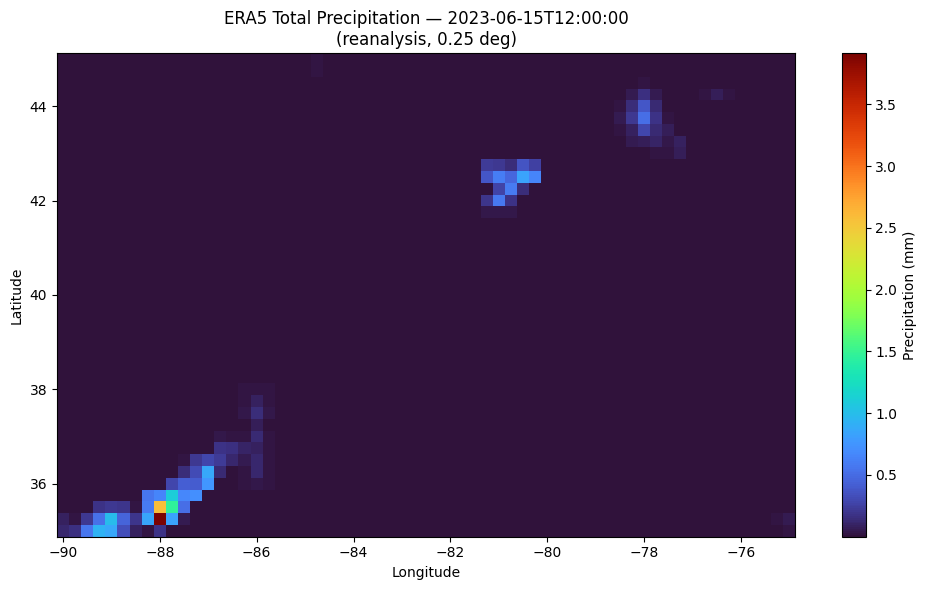

In [2]:
# Plot ERA5 reanalysis precipitation
precip_mm = field.data * 1000.0  # meters -> mm

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    field.longitudes - 360,  # convert 270-285 -> -90 to -75
    field.latitudes,
    precip_mm,
    cmap="turbo",
    shading="auto",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"ERA5 Total Precipitation — {datetime_str}\n(reanalysis, 0.25 deg)")
plt.colorbar(im, ax=ax, label="Precipitation (mm)")
plt.tight_layout()
plt.show()

Rust-rendered PNG: 10507 bytes


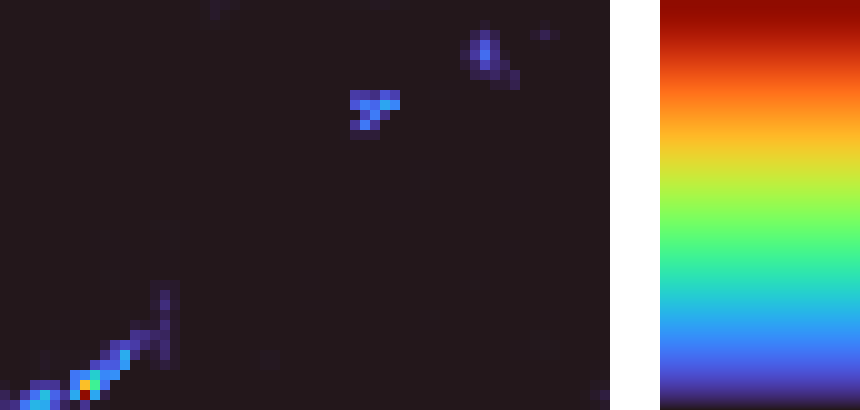

In [3]:
# Also render via corduroy's built-in Rust renderer (turbo colormap + colorbar)
png_bytes = corduroy.render_heatmap(field)
print(f"Rust-rendered PNG: {len(png_bytes)} bytes")

from IPython.display import Image, display
display(Image(data=png_bytes))

## Part 2: NeuralGCM Forecast (JAX)

NeuralGCM is a hybrid physics-ML atmospheric model (Kochkov et al., Nature 2024). It needs:
- **Full-globe ERA5 initial conditions** (all prognostic variables, all pressure levels)
- **GPU recommended** (CPU works but ~100x slower)

Install: `uv sync --group forecast`

The workflow:
1. Load a pretrained checkpoint from GCS
2. Load ERA5 initial state via xarray (full globe)
3. Regrid to NeuralGCM's Gaussian grid
4. Run forward forecast via `model.unroll()`
5. Extract the bbox and pass to corduroy for rendering

In [ ]:
import os

# Workaround for XLA autotuning failures on consumer GPUs (e.g., RTX 4080).
# JAX 0.9+ can trigger "Autotuning failed for HLO ... No valid config found!"
# during model.unroll(). Disabling autotuning uses default kernel configs instead.
os.environ["XLA_FLAGS"] = os.environ.get("XLA_FLAGS", "") + " --xla_gpu_autotune_level=0"

import gcsfs
import pickle
import xarray  # needed for NeuralGCM's data_to_xarray / inputs_from_xarray
import jax
import neuralgcm

print(f"JAX backend: {jax.default_backend()}")
print(f"JAX devices: {jax.devices()}")

In [5]:
# Choose NeuralGCM resolution:
#   "0_7" — sharpest (78 km), best 1-3 day, 119s/10-day forecast, 4.2 GB VRAM
#   "1_4" — balanced (155 km), climate-stable, 12.6s/10-day, 1.1 GB VRAM
#   "2_8" — fastest (310 km), lightweight, 2.5s/10-day, 255 MB VRAM
RESOLUTION = "0_7"

gcs = gcsfs.GCSFileSystem(token="anon")
ckpt_path = f"gs://neuralgcm/models/v1/deterministic_{RESOLUTION}_deg.pkl"
print(f"Loading checkpoint: {ckpt_path}")

with gcs.open(ckpt_path, "rb") as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

print(f"Input variables: {model.input_variables}")
print(f"Forcing variables: {model.forcing_variables}")
print(f"Timestep: {model.timestep}")

Loading checkpoint: gs://neuralgcm/models/v1/deterministic_0_7_deg.pkl
Input variables: ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
Forcing variables: ['sea_ice_cover', 'sea_surface_temperature']
Timestep: 3600 seconds


In [6]:
# Load ERA5 initial conditions via Rust (parallel multi-variable fetch)
# This replaces the xarray.open_zarr approach — corduroy fetches all variables
# concurrently using tokio, one task per variable.

all_vars = model.input_variables + model.forcing_variables
print(f"Fetching {len(all_vars)} variables via corduroy (Rust):")
for v in all_vars:
    print(f"  - {v}")

dataset = corduroy.fetch_era5_global(
    variables=all_vars,
    time_start="2023-06-15T00:00:00",
    time_end="2023-06-18T00:00:00",
    time_step_hours=6,
)

print(f"\n{dataset}")
print(f"Times: {dataset.times[:3]}... ({len(dataset.times)} total)")

# Convert to xarray.Dataset for NeuralGCM compatibility
sliced = dataset.to_xarray()
print(f"\nxarray Dataset: {list(sliced.data_vars)}")
print(f"Shape example (temperature): {sliced['temperature'].shape}")

Fetching 9 variables via corduroy (Rust):
  - geopotential
  - specific_humidity
  - temperature
  - u_component_of_wind
  - v_component_of_wind
  - specific_cloud_ice_water_content
  - specific_cloud_liquid_water_content
  - sea_ice_cover
  - sea_surface_temperature

Era5Dataset(variables=["geopotential", "sea_ice_cover", "sea_surface_temperature", "specific_cloud_ice_water_content", "specific_cloud_liquid_water_content", "specific_humidity", "temperature", "u_component_of_wind", "v_component_of_wind"], times=13, lats=721, lons=1440)
Times: ['2023-06-15T00:00:00', '2023-06-15T06:00:00', '2023-06-15T12:00:00']... (13 total)

xarray Dataset: ['specific_cloud_ice_water_content', 'u_component_of_wind', 'specific_cloud_liquid_water_content', 'v_component_of_wind', 'sea_ice_cover', 'specific_humidity', 'temperature', 'sea_surface_temperature', 'geopotential']
Shape example (temperature): (13, 37, 721, 1440)


In [ ]:
# Regrid ERA5 (0.25 deg equirectangular) to NeuralGCM's native Gaussian grid
# using corduroy's conservative regridder (Rust, area-weighted with NaN fill)

model_grid = model.data_coords.horizontal

regridder = corduroy.ConservativeRegridder(
    dataset.latitudes,            # ERA5 721-pt lat grid
    dataset.longitudes,           # ERA5 1440-pt lon grid
    model_grid.latitudes,         # NeuralGCM Gaussian lat grid
    model_grid.longitudes,        # NeuralGCM Gaussian lon grid
)
print(f"Regridding ERA5 {len(dataset.latitudes)}x{len(dataset.longitudes)} -> "
      f"{regridder.target_shape} (model grid)")

regridded = regridder.regrid_dataset(dataset)
eval_era5 = regridded.to_xarray()

print(f"Regridded to model grid: {eval_era5['temperature'].shape}")

In [ ]:
# Encode initial state and run a 3-day forecast
import numpy as np

inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
rng_key = jax.random.key(42)

print("Encoding initial state...")
initial_state = model.encode(inputs, input_forcings, rng_key)

# Forcings for the forecast period (SST + sea ice)
all_forcings = model.forcings_from_xarray(eval_era5)

# Run forecast: 12 outer steps x 6h inner steps = 3 days
outer_steps = 12
inner_steps = 6  # hours per outer step
timedelta = np.timedelta64(1, "h") * inner_steps

print(f"Running {outer_steps * inner_steps}h forecast ({outer_steps} steps x {inner_steps}h)...")
final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
print("Forecast complete.")

In [ ]:
# Decode predictions to xarray
times = eval_era5.time.values[:outer_steps]
predictions_ds = model.data_to_xarray(predictions, times=times)

print(f"Forecast variables: {list(predictions_ds.data_vars)}")
print(f"Forecast shape: {predictions_ds['temperature'].shape}")
print(f"Forecast grid: {predictions_ds.latitude.values.shape[0]} lat x {predictions_ds.longitude.values.shape[0]} lon")

## Part 3: Compare Reanalysis vs Forecast

Extract the forecast for our bounding box and render with corduroy.

At 0.7 deg, NeuralGCM outputs ~14 lat x ~21 lon points for our 10x15 deg bbox. At 2.8 deg, only ~4 x ~5 points. The deterministic models output atmospheric state variables (temperature, humidity, wind) — for direct precipitation output, use `v1_precip/stochastic_precip_2_8_deg.pkl`.

In [ ]:
# Extract forecast temperature at 850 hPa for our bounding box
# NeuralGCM uses 0-360 longitude convention, same as ERA5 internally
lon_min_360, lon_max_360 = 270.0, 285.0  # -90 to -75 in 0-360
lat_min, lat_max = 35.0, 45.0

forecast_bbox = predictions_ds.sel(
    latitude=slice(lat_max, lat_min),   # latitude is N->S
    longitude=slice(lon_min_360, lon_max_360),
    level=850,
)

# Pick the last forecast timestep (3 days out)
forecast_t850 = forecast_bbox["temperature"].isel(time=-1).values

# Also get the ERA5 reanalysis for the same time/region for comparison
era5_bbox = eval_era5.sel(
    latitude=slice(lat_max, lat_min),
    longitude=slice(lon_min_360, lon_max_360),
    level=850,
)
era5_t850 = era5_bbox["temperature"].isel(time=-1).values

print(f"Forecast T850 shape: {forecast_t850.shape}")
print(f"ERA5 T850 shape:     {era5_t850.shape}")
print(f"Forecast range: {forecast_t850.min():.1f} - {forecast_t850.max():.1f} K")
print(f"ERA5 range:     {era5_t850.min():.1f} - {era5_t850.max():.1f} K")

In [ ]:
# Side-by-side comparison: ERA5 reanalysis vs NeuralGCM forecast
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

forecast_lats = forecast_bbox.latitude.values
forecast_lons = forecast_bbox.longitude.values - 360  # back to -90..-75

era5_lats = era5_bbox.latitude.values
era5_lons = era5_bbox.longitude.values - 360

vmin = min(era5_t850.min(), forecast_t850.min())
vmax = max(era5_t850.max(), forecast_t850.max())

# ERA5 (regridded to model resolution for fair comparison)
im0 = axes[0].pcolormesh(era5_lons, era5_lats, era5_t850, cmap="RdYlBu_r",
                          vmin=vmin, vmax=vmax, shading="auto")
axes[0].set_title(f"ERA5 Reanalysis\n({RESOLUTION.replace('_','.')} deg regridded)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# NeuralGCM forecast
im1 = axes[1].pcolormesh(forecast_lons, forecast_lats, forecast_t850, cmap="RdYlBu_r",
                          vmin=vmin, vmax=vmax, shading="auto")
axes[1].set_title(f"NeuralGCM 3-day Forecast\n({RESOLUTION.replace('_','.')} deg)")
axes[1].set_xlabel("Longitude")

# Difference
diff = forecast_t850 - era5_t850
dmax = max(np.abs(diff).max(), 0.1)
im2 = axes[2].pcolormesh(forecast_lons, forecast_lats, diff, cmap="RdBu_r",
                          vmin=-dmax, vmax=dmax, shading="auto")
axes[2].set_title(f"Forecast - Reanalysis\n(RMSE: {np.sqrt(np.mean(diff**2)):.2f} K)")
axes[2].set_xlabel("Longitude")

plt.colorbar(im0, ax=axes[0], label="T850 (K)")
plt.colorbar(im1, ax=axes[1], label="T850 (K)")
plt.colorbar(im2, ax=axes[2], label="ΔT (K)")
plt.tight_layout()
plt.show()

## Part 4: Pass NeuralGCM output through Corduroy's Rust renderer

Demonstrates the Rust<->Python bridge: NeuralGCM produces numpy arrays, corduroy renders them via Rust.

In [ ]:
# Wrap the NeuralGCM forecast output as a corduroy PrecipitationField
# (reusing the render pipeline even though this is temperature, not precip)
forecast_field = corduroy.make_precipitation_field(
    forecast_t850.astype(np.float32),
    forecast_lats.astype(np.float64),
    (forecast_lons).astype(np.float64),
    "2023-06-18T00:00:00",  # 3 days after init
)

print(f"Corduroy field from NeuralGCM: {forecast_field}")
png = corduroy.render_heatmap(forecast_field)
print(f"Rendered {len(png)} bytes via Rust")
display(Image(data=png))

## Summary

| Step | Implementation | Notes |
|------|---------------|-------|
| ERA5 fetch (bbox, 1 var) | **Rust** (corduroy) | `fetch_precipitation()` |
| ERA5 fetch (global, all vars) | **Rust** (corduroy) | `fetch_era5_global()` — parallel tokio tasks per variable |
| Conservative regrid (equirect → Gaussian) | **Rust** (corduroy) | `regrid_dataset()` — area-weighted with sin(lat), NaN flood fill |
| NeuralGCM forecast | JAX (GPU) | Stays in Python — neural net inference |
| Render heatmap | **Rust** (corduroy) | `render_heatmap()` / `render_heatmap_to_file()` |

### Available NeuralGCM checkpoints
| Path | Resolution | Notes |
|------|-----------|-------|
| `v1/deterministic_0_7_deg.pkl` | 0.7° (78 km) | Sharpest, best 1-3 day |
| `v1/deterministic_1_4_deg.pkl` | 1.4° (155 km) | Climate-stable |
| `v1/deterministic_2_8_deg.pkl` | 2.8° (310 km) | Fastest |
| `v1/stochastic_1_4_deg.pkl` | 1.4° | Best ensemble (matches ECMWF-ENS) |
| `v1_precip/stochastic_precip_2_8_deg.pkl` | 2.8° | Direct precipitation output |